In [9]:
import numpy as np
import pandas as pd
import gzip
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# Load the compressed BED-like file
file_path = "mapped.bed.gz"

# Read the file and show a few lines to understand structure
with gzip.open(file_path, 'rt') as f:
    lines = [next(f) for _ in range(5)]

In [17]:
xy_counter = {}

# Process the full file to extract (X, Y, Z)
with gzip.open(file_path, 'rt') as f:
    for line in f:
        cols = line.strip().split('\t')
        try:
            # Column indices are zero-based
            c1 = (int(cols[2]) + int(cols[3])) // 2
            c2 = (int(cols[8]) + int(cols[9])) // 2
            x = c2 - c1
            y = int(cols[9]) - int(cols[8])

            if (x, y) in xy_counter:
                xy_counter[(x,y)] += 1
            else:
                xy_counter[(x,y)] = 1
                
        except (IndexError, ValueError):
            continue  # Skip malformed lines

x = set()
y = set()

for key in xy_counter.keys():
    x.add(key[0])
    y.add(key[1])
    
x = sorted(x)
y = sorted(y)


x_index = {index : i for i, index in enumerate(x)}
y_index = {index : i for i, index in enumerate(y)}

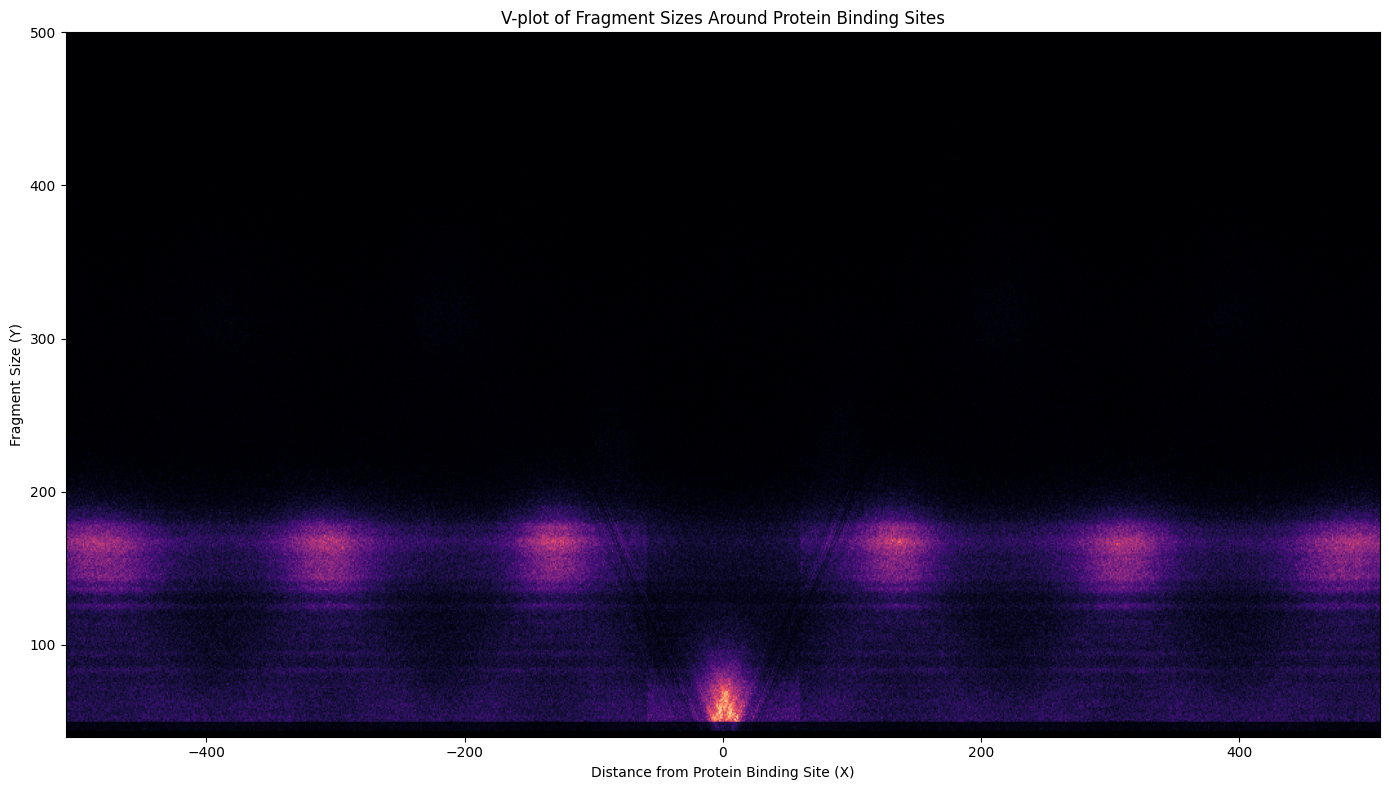

In [19]:
heat = np.zeros((len(y), len(x)))

for (x1, y1), z1 in xy_counter.items():
    heat[y_index[y1]][x_index[x1]] = z1

# Plot heatmap
plt.figure(figsize=(14, 8))
plt.imshow(heat, aspect="auto", origin="lower", extent=[min(x), max(x), min(y), max(y)], cmap = "magma")
plt.title("V-plot of Fragment Sizes Around Protein Binding Sites")
plt.xlabel("Distance from Protein Binding Site (X)")
plt.ylabel("Fragment Size (Y)")
plt.tight_layout()
plt.show()